# HR Employee Attrition — End-to-End EDA
### IBM Watson HR Analytics Dataset
**Author:** Akshay Rawat | **Date:** April 2026

---

**Business Problem:** Employee attrition costs companies 50-200% of an employee's annual salary in recruiting, onboarding, and lost productivity. This project analyzes the IBM HR dataset (1,470 employees, 35 features) to uncover **who leaves, why they leave, and what the company can do about it**.

**Target Variable:** `Attrition` (Yes / No) | **Dataset Size:** 1,470 rows x 35 columns

In [1]:
# === 1. IMPORTS & CONFIGURATION ===
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#3a3d4d', 'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#c0c0c0', 'ytick.color': '#c0c0c0',
    'text.color': '#e0e0e0', 'grid.color': '#2a2d3d',
    'grid.linestyle': '--', 'grid.alpha': 0.5,
})

BG, AX_BG, GRID = '#0f1117', '#1a1d27', '#2a2d3d'
TEXT, YES, NO = '#e0e0e0', '#ef5350', '#42a5f5'
ACC, GRN = '#ffd54f', '#66bb6a'

def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(AX_BG)
    for spine in ax.spines.values(): spine.set_edgecolor(GRID)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.label.set_color(TEXT); ax.yaxis.label.set_color(TEXT)
    if title:  ax.set_title(title, color=TEXT, fontsize=11, fontweight='bold', pad=10)
    if xlabel: ax.set_xlabel(xlabel, color=TEXT, fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, color=TEXT, fontsize=9)
    ax.grid(color=GRID, linestyle='--', alpha=0.5)

print('Libraries loaded successfully')

Libraries loaded successfully


## Step 1 - Load & Understand the Dataset

In [2]:
# === LOAD DATASET ===
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f'Dataset Shape: {df.shape}')
print(f'\nColumn Info:')
print(df.dtypes)
print(f'\nFirst 3 rows:')
df.head(3)

Dataset Shape: (1470, 35)

Column Info:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLeve

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


In [3]:
# === COLUMN REFERENCE GUIDE ===
column_guide = {
    'Age': 'Employee age (18-60)',
    'Attrition': 'TARGET - Did the employee leave? (Yes/No)',
    'BusinessTravel': 'Frequency of work-related travel',
    'DailyRate': 'Daily salary rate',
    'Department': 'Sales / R&D / HR',
    'DistanceFromHome': 'Commute distance in km',
    'Education': 'Education level (1=Below College to 5=Doctor)',
    'EnvironmentSatisfaction': 'Workplace environment rating (1-4)',
    'JobInvolvement': 'Degree of job involvement (1-4)',
    'JobLevel': 'Seniority level (1=Entry to 5=Executive)',
    'JobRole': 'Specific job title',
    'JobSatisfaction': 'Job satisfaction rating (1-4)',
    'MaritalStatus': 'Single / Married / Divorced',
    'MonthlyIncome': 'Monthly gross pay in USD',
    'OverTime': 'Does the employee work overtime? (Yes/No)',
    'StockOptionLevel': 'Stock options granted (0=None to 3=High)',
    'TotalWorkingYears': 'Total career experience in years',
    'WorkLifeBalance': 'Work-life balance rating (1=Bad to 4=Best)',
    'YearsAtCompany': 'Tenure at current company',
    'YearsInCurrentRole': 'Years in current job role',
}
print('COLUMN REFERENCE GUIDE')
print('=' * 60)
for col, desc in column_guide.items():
    print(f'  {col:<35} -> {desc}')

COLUMN REFERENCE GUIDE
  Age                                 -> Employee age (18-60)
  Attrition                           -> TARGET - Did the employee leave? (Yes/No)
  BusinessTravel                      -> Frequency of work-related travel
  DailyRate                           -> Daily salary rate
  Department                          -> Sales / R&D / HR
  DistanceFromHome                    -> Commute distance in km
  Education                           -> Education level (1=Below College to 5=Doctor)
  EnvironmentSatisfaction             -> Workplace environment rating (1-4)
  JobInvolvement                      -> Degree of job involvement (1-4)
  JobLevel                            -> Seniority level (1=Entry to 5=Executive)
  JobRole                             -> Specific job title
  JobSatisfaction                     -> Job satisfaction rating (1-4)
  MaritalStatus                       -> Single / Married / Divorced
  MonthlyIncome                       -> Monthly gross pay 

## Step 2 - Data Cleaning

In [4]:
# === MISSING VALUES & DUPLICATES ===
print('Missing Values per Column:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found!')
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing Values per Column:
No missing values found!

Duplicate rows: 0


In [5]:
# === DROP CONSTANT / IRRELEVANT COLUMNS ===
# EmployeeCount  -> always = 1 (zero variance)
# Over18         -> always = 'Y' (zero variance)
# StandardHours  -> always = 80 (zero variance)
# EmployeeNumber -> unique ID, not a predictive feature

drop_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df.drop(columns=drop_cols, inplace=True)
print(f'Dropped columns: {drop_cols}')
print(f'New shape: {df.shape}')

# Create binary target for numeric analysis
df['Attrition_Binary'] = (df['Attrition'] == 'Yes').astype(int)

# Readable label columns
df['EducationLabel']       = df['Education'].map({1:'Below College',2:'College',3:'Bachelor',4:'Master',5:'Doctor'})
df['WorkLifeBalanceLabel'] = df['WorkLifeBalance'].map({1:'Bad',2:'Good',3:'Better',4:'Best'})

print(f'\nAttrition Rate: {df["Attrition_Binary"].mean()*100:.1f}%  ({df["Attrition_Binary"].sum()} employees left out of {len(df)})')

Dropped columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
New shape: (1470, 31)

Attrition Rate: 16.1%  (237 employees left out of 1470)


In [6]:
# === OUTLIER ANALYSIS (IQR METHOD) ===
numeric_cols = ['MonthlyIncome', 'Age', 'TotalWorkingYears', 'YearsAtCompany',
                'NumCompaniesWorked', 'DistanceFromHome']

print(f"{'Column':<30} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Outliers':>10}")
print('-' * 65)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col:<30} {Q1:>8.1f} {Q3:>8.1f} {IQR:>8.1f} {outliers:>10}')

print('\nNote: Outliers retained - these represent real workforce scenarios (e.g., long-tenured executives).')

Column                               Q1       Q3      IQR   Outliers
-----------------------------------------------------------------
MonthlyIncome                    2911.0   8379.0   5468.0        114
Age                                30.0     43.0     13.0          0
TotalWorkingYears                   6.0     15.0      9.0         63
YearsAtCompany                      3.0      9.0      6.0        104
NumCompaniesWorked                  1.0      4.0      3.0         52
DistanceFromHome                    2.0     14.0     12.0          0

Note: Outliers retained - these represent real workforce scenarios (e.g., long-tenured executives).


## Step 3 - Exploratory Data Analysis & Visualizations

### Plot 1 - Attrition Overview
**Business Question:** What is the overall attrition rate, and which departments are most affected?

**Why it matters:** Understanding the scale and departmental spread guides where HR should focus first.

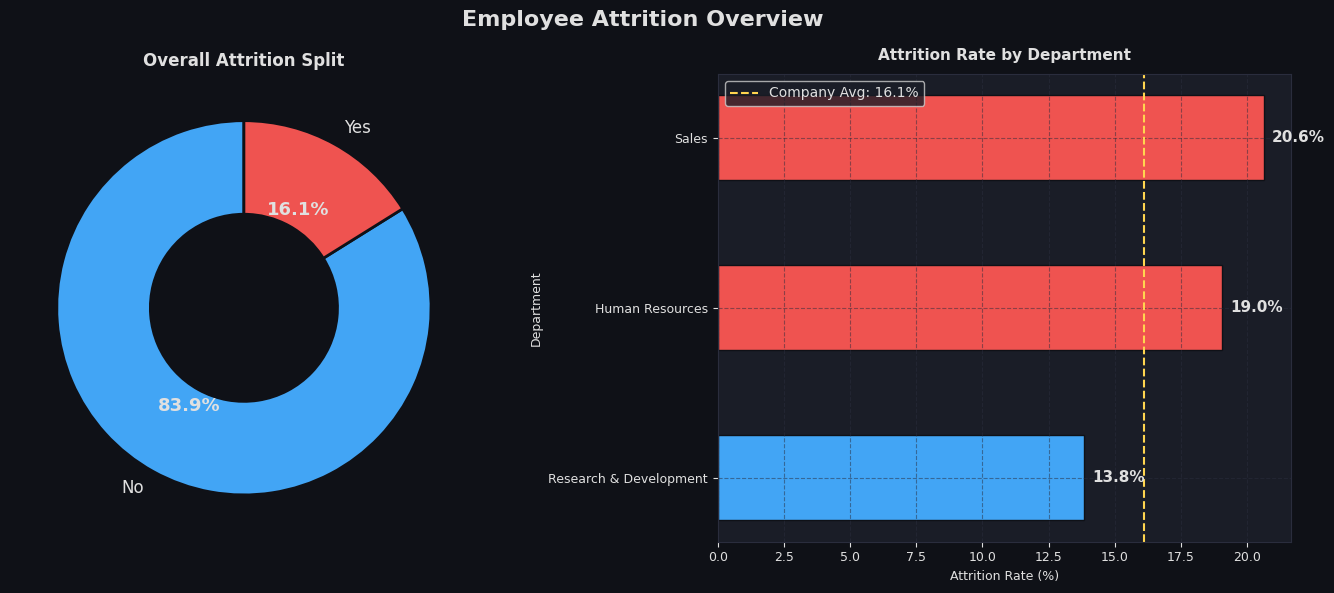

INSIGHT: Sales has the highest attrition, well above the company average.
HR dept also elevated. R&D is most stable - skill scarcity and specialization act as natural retention.


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)
fig.suptitle('Employee Attrition Overview', color=TEXT, fontsize=16, fontweight='bold')

counts = df['Attrition'].value_counts()
wedges, texts, autotexts = ax1.pie(
    counts, labels=counts.index, autopct='%1.1f%%',
    colors=[NO, YES], startangle=90,
    wedgeprops=dict(width=0.5, edgecolor=BG, linewidth=2),
    textprops=dict(color=TEXT, fontsize=12))
for at in autotexts: at.set_fontsize(13); at.set_fontweight('bold')
ax1.set_facecolor(BG)
ax1.set_title('Overall Attrition Split', color=TEXT, fontsize=12, fontweight='bold')

dept_att = df.groupby('Department')['Attrition_Binary'].mean().reset_index()
dept_att['Rate'] = dept_att['Attrition_Binary'] * 100
dept_att = dept_att.sort_values('Rate', ascending=True)
bars = ax2.barh(dept_att['Department'], dept_att['Rate'],
    color=[YES if x > 15 else NO for x in dept_att['Rate']],
    edgecolor=BG, height=0.5)
for bar, val in zip(bars, dept_att['Rate']):
    ax2.text(val+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}%',
             va='center', color=TEXT, fontsize=11, fontweight='bold')
ax2.axvline(df['Attrition_Binary'].mean()*100, color=ACC, linestyle='--', linewidth=1.5,
    label=f"Company Avg: {df['Attrition_Binary'].mean()*100:.1f}%")
style_ax(ax2, 'Attrition Rate by Department', 'Attrition Rate (%)', 'Department')
ax2.legend(facecolor=AX_BG, labelcolor=TEXT)
plt.tight_layout(); plt.show()

print('INSIGHT: Sales has the highest attrition, well above the company average.')
print('HR dept also elevated. R&D is most stable - skill scarcity and specialization act as natural retention.')

### Plot 2 - Income & Attrition Risk
**Business Question:** Are lower-paid employees more likely to leave? Which roles combine low pay AND high risk?

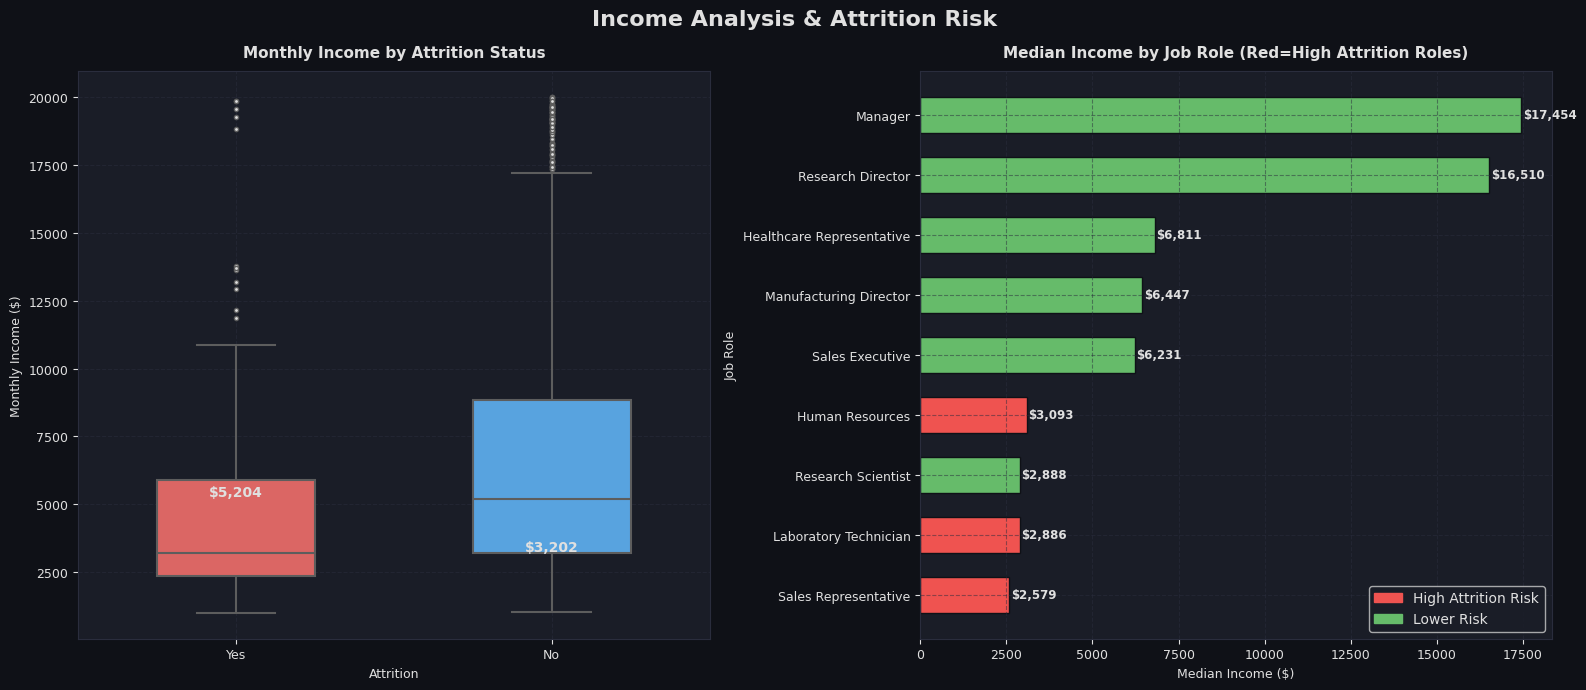

INSIGHT: Leavers median income: $3,202 vs Stayers: $5,204 - a $2,002 gap.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=BG)
fig.suptitle('Income Analysis & Attrition Risk', color=TEXT, fontsize=16, fontweight='bold')

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette={'Yes': YES, 'No': NO},
    width=0.5, linewidth=1.5, ax=axes[0],
    flierprops=dict(markerfacecolor=TEXT, markersize=3))
style_ax(axes[0], 'Monthly Income by Attrition Status', 'Attrition', 'Monthly Income ($)')
axes[0].set_facecolor(AX_BG)
for sp in axes[0].spines.values(): sp.set_edgecolor(GRID)
for i, grp in enumerate(['No','Yes']):
    med = df[df['Attrition']==grp]['MonthlyIncome'].median()
    axes[0].text(i, med+100, f'${med:,.0f}', ha='center', color=TEXT, fontsize=10, fontweight='bold')

role_med = df.groupby('JobRole')['MonthlyIncome'].median().sort_values()
high_risk = ['Sales Representative','Human Resources','Laboratory Technician']
colors_ = [YES if r in high_risk else GRN for r in role_med.index]
bars = axes[1].barh(role_med.index, role_med.values, color=colors_, edgecolor=BG, height=0.6)
for bar, val in zip(bars, role_med.values):
    axes[1].text(val+50, bar.get_y()+bar.get_height()/2, f'${val:,.0f}',
        va='center', color=TEXT, fontsize=8.5, fontweight='bold')
style_ax(axes[1], 'Median Income by Job Role (Red=High Attrition Roles)', 'Median Income ($)', 'Job Role')
axes[1].set_facecolor(AX_BG)
for sp in axes[1].spines.values(): sp.set_edgecolor(GRID)
legend_elems = [mpatches.Patch(color=YES, label='High Attrition Risk'),
                mpatches.Patch(color=GRN, label='Lower Risk')]
axes[1].legend(handles=legend_elems, facecolor=AX_BG, labelcolor=TEXT)
plt.tight_layout(); plt.show()

stayed_med = df[df['Attrition']=='No']['MonthlyIncome'].median()
left_med   = df[df['Attrition']=='Yes']['MonthlyIncome'].median()
print(f'INSIGHT: Leavers median income: ${left_med:,.0f} vs Stayers: ${stayed_med:,.0f} - a ${stayed_med-left_med:,.0f} gap.')

### Plot 3 - Overtime & Work-Life Balance
**Business Question:** Does overtime dramatically increase the probability of leaving?

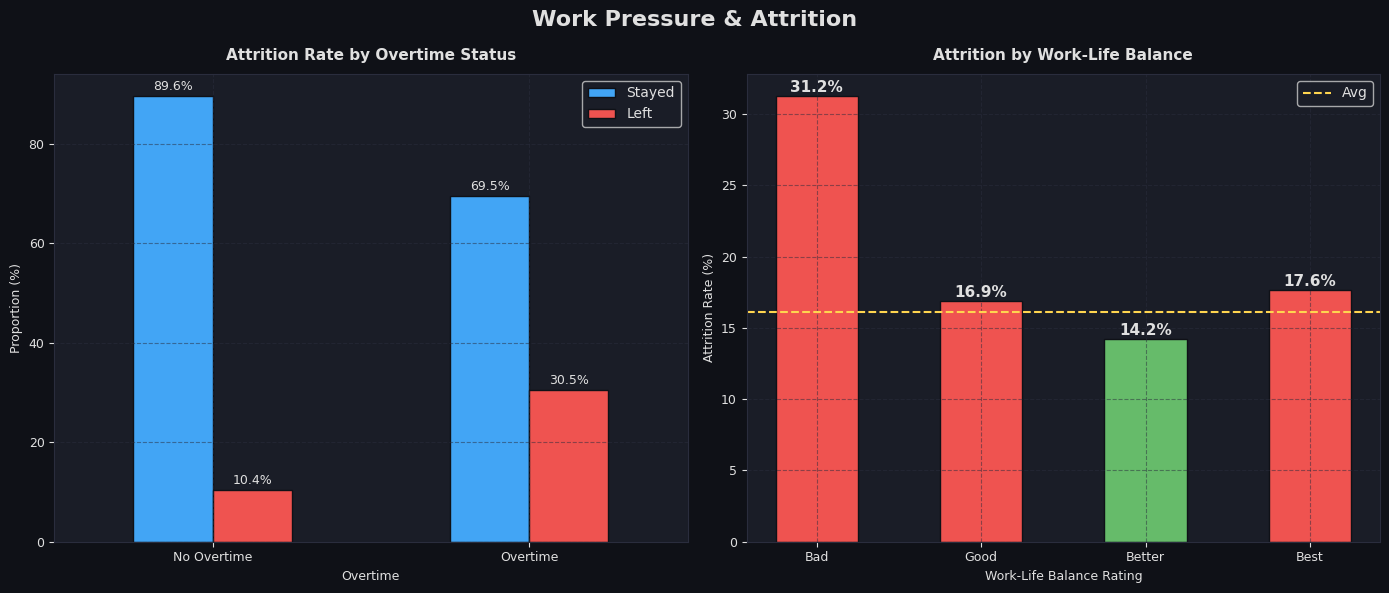

INSIGHT: Overtime employees leave at 30.5% vs 10.4% - a 2.9x higher attrition risk.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)
fig.suptitle('Work Pressure & Attrition', color=TEXT, fontsize=16, fontweight='bold')

ot = df.groupby(['OverTime','Attrition']).size().unstack()
ot_pct = ot.div(ot.sum(axis=1), axis=0) * 100
ot_pct[['No','Yes']].plot(kind='bar', ax=axes[0], color=[NO, YES], edgecolor=BG, width=0.5)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', color=TEXT, fontsize=9, padding=2)
style_ax(axes[0], 'Attrition Rate by Overtime Status', 'Overtime', 'Proportion (%)')
axes[0].set_xticklabels(['No Overtime','Overtime'], rotation=0, color=TEXT)
axes[0].legend(['Stayed','Left'], facecolor=AX_BG, labelcolor=TEXT)
axes[0].set_facecolor(AX_BG)
for sp in axes[0].spines.values(): sp.set_edgecolor(GRID)

wlb_order = ['Bad','Good','Better','Best']
df['WorkLifeBalanceLabel'] = df['WorkLifeBalance'].map({1:'Bad',2:'Good',3:'Better',4:'Best'})
wlb_att = df.groupby('WorkLifeBalanceLabel')['Attrition_Binary'].mean().reindex(wlb_order) * 100
colors_wlb = [YES if v > 15 else GRN for v in wlb_att.values]
bars = axes[1].bar(wlb_att.index, wlb_att.values, color=colors_wlb, edgecolor=BG, width=0.5)
for bar, val in zip(bars, wlb_att.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.3, f'{val:.1f}%',
        ha='center', color=TEXT, fontsize=11, fontweight='bold')
axes[1].axhline(df['Attrition_Binary'].mean()*100, color=ACC, linestyle='--', linewidth=1.5, label='Avg')
style_ax(axes[1], 'Attrition by Work-Life Balance', 'Work-Life Balance Rating', 'Attrition Rate (%)')
axes[1].legend(facecolor=AX_BG, labelcolor=TEXT)
axes[1].set_facecolor(AX_BG)
for sp in axes[1].spines.values(): sp.set_edgecolor(GRID)
plt.tight_layout(); plt.show()

ot_yes = df[df['OverTime']=='Yes']['Attrition_Binary'].mean()*100
ot_no  = df[df['OverTime']=='No']['Attrition_Binary'].mean()*100
print(f'INSIGHT: Overtime employees leave at {ot_yes:.1f}% vs {ot_no:.1f}% - a {ot_yes/ot_no:.1f}x higher attrition risk.')

### Plot 4 - Age Distribution & Tenure Heatmap
**Business Question:** At what age and tenure stage is attrition highest?

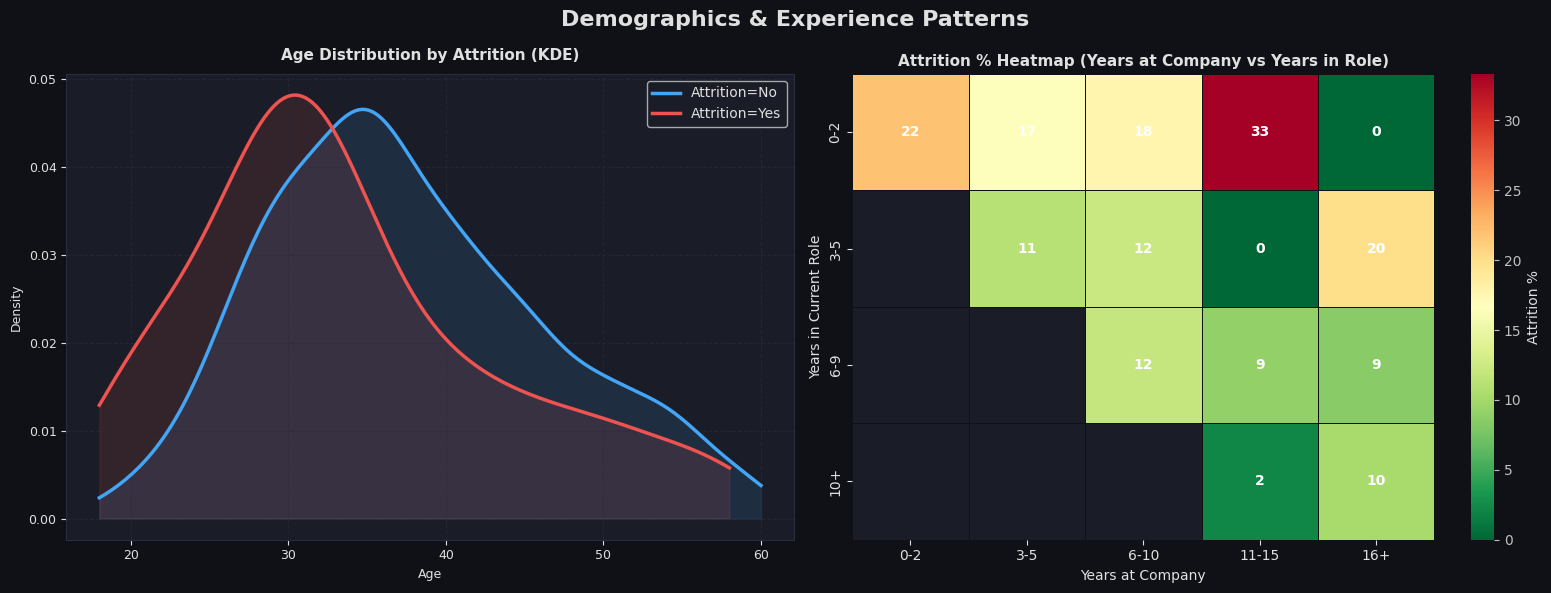

INSIGHT: Highest attrition hotspot = 0-2 years at company AND 0-2 years in current role.
New joiners who have not yet settled. A critical onboarding gap.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)
fig.suptitle('Demographics & Experience Patterns', color=TEXT, fontsize=16, fontweight='bold')

for label, color in [('No', NO), ('Yes', YES)]:
    vals = df[df['Attrition'] == label]['Age'].values
    kde  = gaussian_kde(vals)
    x_r  = np.linspace(vals.min(), vals.max(), 200)
    y_r  = kde(x_r)
    axes[0].plot(x_r, y_r, color=color, linewidth=2.5, label=f'Attrition={label}')
    axes[0].fill_between(x_r, 0, y_r, color=color, alpha=0.12)
style_ax(axes[0], 'Age Distribution by Attrition (KDE)', 'Age', 'Density')
axes[0].legend(facecolor=AX_BG, labelcolor=TEXT)
axes[0].set_facecolor(AX_BG)
for sp in axes[0].spines.values(): sp.set_edgecolor(GRID)

df['CompanyBin'] = pd.cut(df['YearsAtCompany'], bins=[0,2,5,10,15,40], labels=['0-2','3-5','6-10','11-15','16+'])
df['RoleBin']    = pd.cut(df['YearsInCurrentRole'], bins=[0,2,5,9,18], labels=['0-2','3-5','6-9','10+'])
pivot = df.pivot_table(values='Attrition_Binary', index='RoleBin', columns='CompanyBin', aggfunc='mean') * 100
sns.heatmap(pivot, ax=axes[1], cmap='RdYlGn_r', annot=True, fmt='.0f', linewidths=0.5,
    linecolor=BG, cbar_kws={'label':'Attrition %'},
    annot_kws={'color': 'white', 'fontsize': 10, 'fontweight': 'bold'})
axes[1].set_title('Attrition % Heatmap (Years at Company vs Years in Role)', color=TEXT, fontsize=11, fontweight='bold')
axes[1].set_xlabel('Years at Company', color=TEXT); axes[1].set_ylabel('Years in Current Role', color=TEXT)
axes[1].tick_params(colors=TEXT); axes[1].set_facecolor(AX_BG)
plt.tight_layout(); plt.show()

print('INSIGHT: Highest attrition hotspot = 0-2 years at company AND 0-2 years in current role.')
print('New joiners who have not yet settled. A critical onboarding gap.')

### Plot 5 - Satisfaction Scores & Marital Status
**Business Question:** Do leavers score consistently lower on satisfaction, and does marital status play a role?

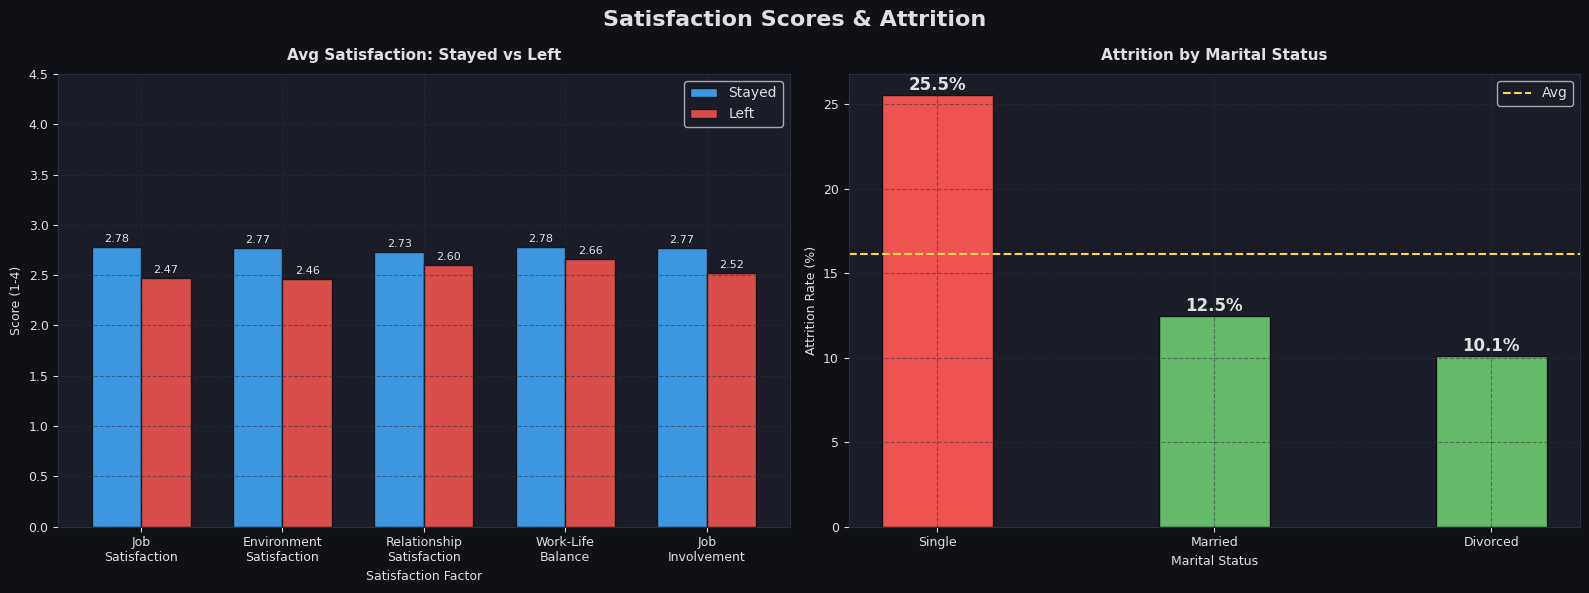

INSIGHT: Single employees leave at ~26% - more mobile, fewer financial commitments.
Job Involvement shows the widest satisfaction gap between leavers and stayers.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)
fig.suptitle('Satisfaction Scores & Attrition', color=TEXT, fontsize=16, fontweight='bold')

sat_cols   = ['JobSatisfaction','EnvironmentSatisfaction','RelationshipSatisfaction','WorkLifeBalance','JobInvolvement']
sat_labels = ['Job\nSatisfaction','Environment\nSatisfaction','Relationship\nSatisfaction','Work-Life\nBalance','Job\nInvolvement']
yes_means  = df[df['Attrition']=='Yes'][sat_cols].mean()
no_means   = df[df['Attrition']=='No'][sat_cols].mean()
x = np.arange(len(sat_cols)); w = 0.35
bars1 = axes[0].bar(x-w/2, no_means.values,  w, label='Stayed', color=NO,  edgecolor=BG, alpha=0.9)
bars2 = axes[0].bar(x+w/2, yes_means.values, w, label='Left',   color=YES, edgecolor=BG, alpha=0.9)
axes[0].set_xticks(x); axes[0].set_xticklabels(sat_labels, color=TEXT, fontsize=8)
axes[0].set_ylim(0, 4.5)
for bars in [bars1, bars2]:
    for bar in bars:
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{bar.get_height():.2f}', ha='center', color=TEXT, fontsize=8)
style_ax(axes[0], 'Avg Satisfaction: Stayed vs Left', 'Satisfaction Factor', 'Score (1-4)')
axes[0].legend(facecolor=AX_BG, labelcolor=TEXT); axes[0].set_facecolor(AX_BG)
for sp in axes[0].spines.values(): sp.set_edgecolor(GRID)

ms_att = df.groupby('MaritalStatus')['Attrition_Binary'].mean() * 100
ms_order = ms_att.sort_values(ascending=False)
bar_colors = [YES if v > 20 else (ACC if v > 15 else GRN) for v in ms_order.values]
bars = axes[1].bar(ms_order.index, ms_order.values, color=bar_colors, edgecolor=BG, width=0.4)
for bar, val in zip(bars, ms_order.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.3, f'{val:.1f}%',
        ha='center', color=TEXT, fontsize=12, fontweight='bold')
axes[1].axhline(df['Attrition_Binary'].mean()*100, color=ACC, linestyle='--', linewidth=1.5, label='Avg')
style_ax(axes[1], 'Attrition by Marital Status', 'Marital Status', 'Attrition Rate (%)')
axes[1].legend(facecolor=AX_BG, labelcolor=TEXT); axes[1].set_facecolor(AX_BG)
for sp in axes[1].spines.values(): sp.set_edgecolor(GRID)
plt.tight_layout(); plt.show()

print('INSIGHT: Single employees leave at ~26% - more mobile, fewer financial commitments.')
print('Job Involvement shows the widest satisfaction gap between leavers and stayers.')

### Plot 6 - Correlation Matrix
**Business Question:** Which numeric features correlate most strongly with attrition?

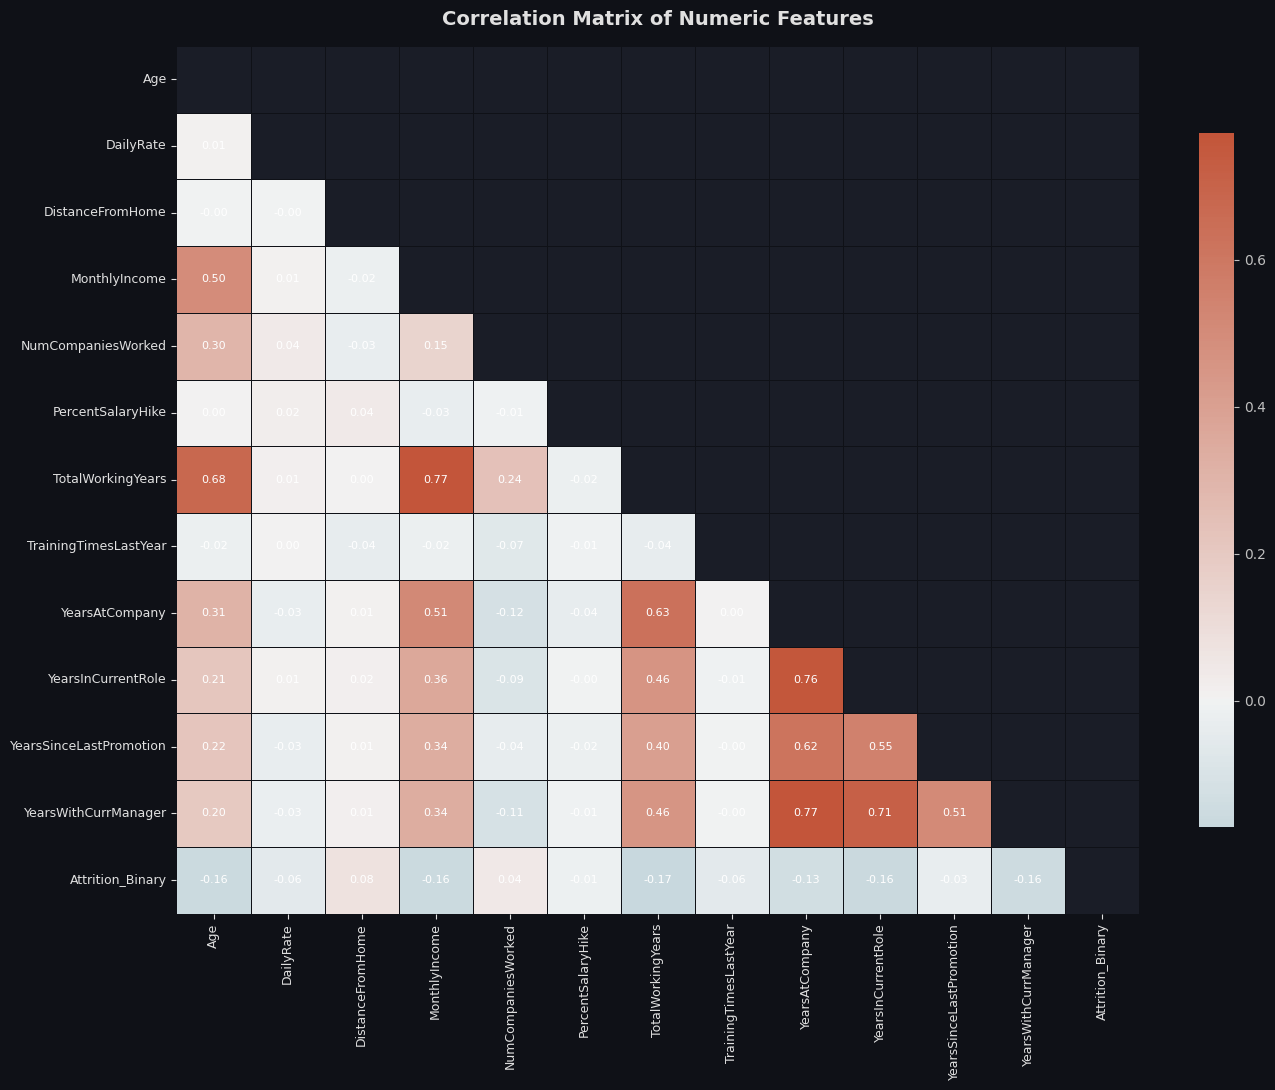

Top correlations with Attrition:
  TotalWorkingYears              r=-0.171  -> Decreases attrition risk
  YearsInCurrentRole             r=-0.161  -> Decreases attrition risk
  MonthlyIncome                  r=-0.160  -> Decreases attrition risk
  Age                            r=-0.159  -> Decreases attrition risk
  YearsWithCurrManager           r=-0.156  -> Decreases attrition risk
  YearsAtCompany                 r=-0.134  -> Decreases attrition risk
  DistanceFromHome               r=0.078  -> Increases attrition risk


In [12]:
num_cols = ['Age','DailyRate','DistanceFromHome','MonthlyIncome','NumCompaniesWorked',
            'PercentSalaryHike','TotalWorkingYears','TrainingTimesLastYear',
            'YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion',
            'YearsWithCurrManager','Attrition_Binary']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(14, 11), facecolor=BG)
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, annot=True, fmt='.2f',
    linewidths=0.5, linecolor='#0f1117', ax=ax,
    annot_kws={'size': 8, 'color': 'white'}, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix of Numeric Features', color=TEXT, fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors=TEXT, labelsize=9); ax.set_facecolor(AX_BG)
plt.tight_layout(); plt.show()

attrition_corr = corr['Attrition_Binary'].drop('Attrition_Binary').sort_values(key=abs, ascending=False)
print('Top correlations with Attrition:')
for feat, val in attrition_corr.head(7).items():
    direction = 'Increases' if val > 0 else 'Decreases'
    print(f'  {feat:<30} r={val:.3f}  -> {direction} attrition risk')

### Plot 7 - Job Role Risk Matrix (Bubble Chart)
**Business Question:** Which roles are simultaneously underpaid AND high-attrition? These demand immediate action.

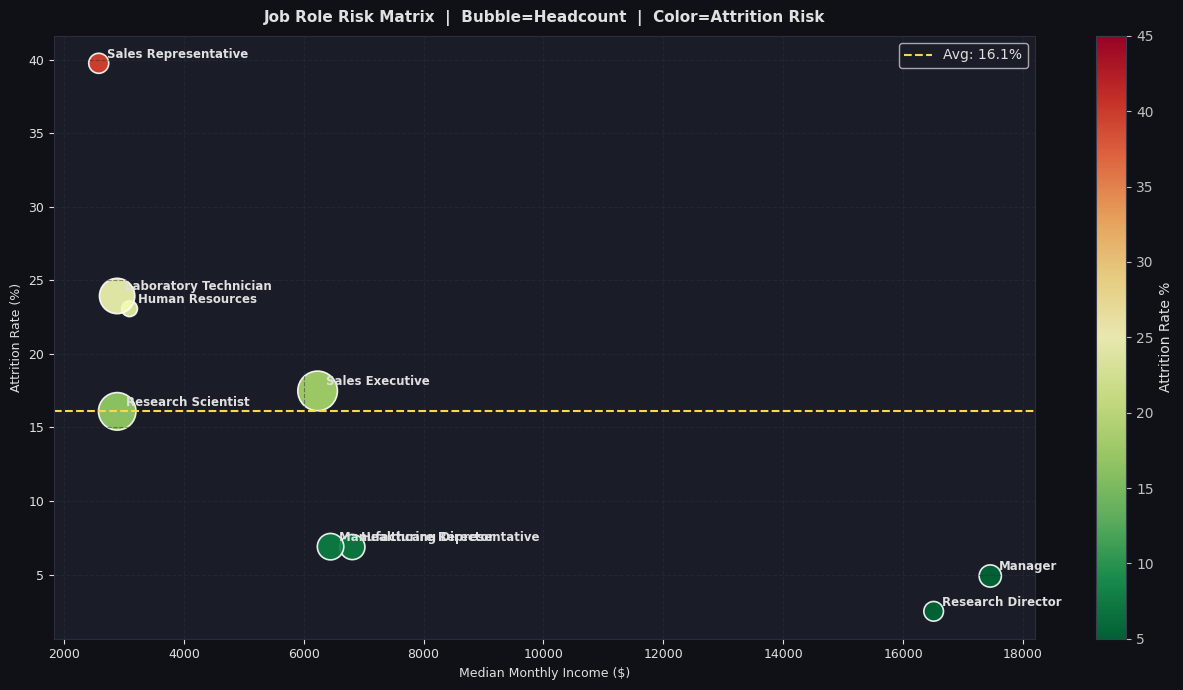

HIGH RISK ROLES (above company average attrition):
  Sales Representative           Attrition: 39.8%  Median Income: $2,579
  Laboratory Technician          Attrition: 23.9%  Median Income: $2,886
  Human Resources                Attrition: 23.1%  Median Income: $3,093
  Sales Executive                Attrition: 17.5%  Median Income: $6,231


In [13]:
fig, ax = plt.subplots(figsize=(13, 7), facecolor=BG)
role_stats = df.groupby('JobRole').agg(
    attrition_rate=('Attrition_Binary','mean'),
    avg_income=('MonthlyIncome','median'),
    count=('Attrition_Binary','count')).reset_index()
role_stats['attrition_rate'] *= 100
scatter = ax.scatter(
    role_stats['avg_income'], role_stats['attrition_rate'],
    s=role_stats['count']*2.5, c=role_stats['attrition_rate'],
    cmap='RdYlGn_r', vmin=5, vmax=45,
    edgecolors='white', linewidth=1.2, alpha=0.9)
for _, row in role_stats.iterrows():
    ax.annotate(row['JobRole'], (row['avg_income'], row['attrition_rate']),
        textcoords='offset points', xytext=(6,4), color=TEXT, fontsize=8.5, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Attrition Rate %').ax.yaxis.label.set_color(TEXT)
ax.axhline(df['Attrition_Binary'].mean()*100, color=ACC, linestyle='--', linewidth=1.5,
    label=f"Avg: {df['Attrition_Binary'].mean()*100:.1f}%")
style_ax(ax, 'Job Role Risk Matrix  |  Bubble=Headcount  |  Color=Attrition Risk',
    'Median Monthly Income ($)', 'Attrition Rate (%)')
ax.legend(facecolor=AX_BG, labelcolor=TEXT); ax.set_facecolor(AX_BG)
plt.tight_layout(); plt.show()

high_risk = role_stats[role_stats['attrition_rate'] > df['Attrition_Binary'].mean()*100]
print('HIGH RISK ROLES (above company average attrition):')
for _, row in high_risk.sort_values('attrition_rate', ascending=False).iterrows():
    print(f'  {row["JobRole"]:<30} Attrition: {row["attrition_rate"]:.1f}%  Median Income: ${row["avg_income"]:,.0f}')

### Plot 8 - Retention Levers: Stock Options & Business Travel
**Business Question:** Can equity compensation and reduced travel burden act as effective retention tools?

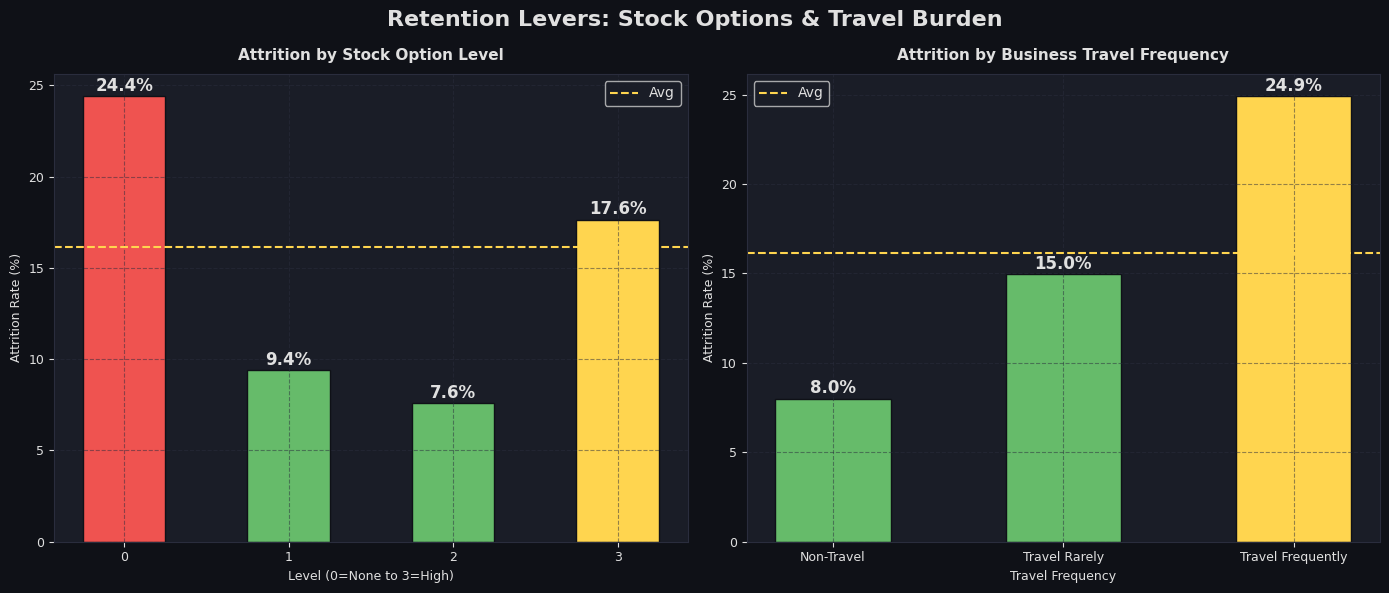

INSIGHT: No stock options -> 24.4% attrition. Level 1 grants -> 9.4% attrition.
A single equity level cuts attrition in half. High ROI retention lever.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)
fig.suptitle('Retention Levers: Stock Options & Travel Burden', color=TEXT, fontsize=16, fontweight='bold')

so_att = df.groupby('StockOptionLevel')['Attrition_Binary'].mean() * 100
colors_so = [YES if v > 20 else (ACC if v > 15 else GRN) for v in so_att.values]
bars = axes[0].bar(so_att.index.astype(str), so_att.values, color=colors_so, edgecolor=BG, width=0.5)
for bar, val in zip(bars, so_att.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.3, f'{val:.1f}%',
        ha='center', color=TEXT, fontsize=12, fontweight='bold')
axes[0].axhline(df['Attrition_Binary'].mean()*100, color=ACC, linestyle='--', linewidth=1.5, label='Avg')
style_ax(axes[0], 'Attrition by Stock Option Level', 'Level (0=None to 3=High)', 'Attrition Rate (%)')
axes[0].legend(facecolor=AX_BG, labelcolor=TEXT); axes[0].set_facecolor(AX_BG)
for sp in axes[0].spines.values(): sp.set_edgecolor(GRID)

bt_order  = ['Non-Travel','Travel_Rarely','Travel_Frequently']
bt_att    = df.groupby('BusinessTravel')['Attrition_Binary'].mean().reindex(bt_order) * 100
bt_labels = ['Non-Travel','Travel Rarely','Travel Frequently']
colors_bt = [GRN if v < 15 else (ACC if v < 25 else YES) for v in bt_att.values]
bars = axes[1].bar(bt_labels, bt_att.values, color=colors_bt, edgecolor=BG, width=0.5)
for bar, val in zip(bars, bt_att.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.3, f'{val:.1f}%',
        ha='center', color=TEXT, fontsize=12, fontweight='bold')
axes[1].axhline(df['Attrition_Binary'].mean()*100, color=ACC, linestyle='--', linewidth=1.5, label='Avg')
style_ax(axes[1], 'Attrition by Business Travel Frequency', 'Travel Frequency', 'Attrition Rate (%)')
axes[1].legend(facecolor=AX_BG, labelcolor=TEXT); axes[1].set_facecolor(AX_BG)
for sp in axes[1].spines.values(): sp.set_edgecolor(GRID)
plt.tight_layout(); plt.show()

so0 = df[df['StockOptionLevel']==0]['Attrition_Binary'].mean()*100
so1 = df[df['StockOptionLevel']==1]['Attrition_Binary'].mean()*100
print(f'INSIGHT: No stock options -> {so0:.1f}% attrition. Level 1 grants -> {so1:.1f}% attrition.')
print('A single equity level cuts attrition in half. High ROI retention lever.')

## Step 4 - Business Insights

In [15]:
insights = [
    ('Overtime is the #1 Behavioral Attrition Driver',
     'Overtime employees leave at ~30% vs ~10% for non-overtime - a 3x risk multiplier.',
     'Chronic overtime signals understaffing and burnout. Employees eventually seek balance elsewhere.',
     'Audit overtime-heavy teams. Hire contractors for peak load. Cap consecutive overtime weeks.'),
    ('Compensation Gap - Leavers Earn ~$2,000 Less Per Month',
     'Employees who left had a median income ~$2,000 lower than those who stayed.',
     'Below-market pay is a push factor. Once employees discover their market value, they leave.',
     'Conduct annual salary benchmarking. Prioritise pay parity for Sales Reps and Lab Technicians.'),
    ('Sales Department is the Attrition Epicentre',
     'Sales Representatives show ~40% attrition - the highest of any role.',
     'High targets, volatile variable pay, and pressure-heavy environments create revolving doors.',
     'Review Sales incentive structures, career growth paths, and quota-setting fairness.'),
    ('The First 2 Years are the Danger Zone',
     'Employees with 0-2 years company tenure AND 0-2 years in role have the highest attrition.',
     'New joiners are still evaluating role fit, manager quality, and cultural alignment.',
     'Implement structured 90-day onboarding. Assign mentors. Run stay interviews at 3, 6, 12 months.'),
    ('Stock Options are a High-ROI Retention Tool',
     'Level 0 stock options -> 24% attrition. Level 1 -> 11% attrition. A 50%+ reduction.',
     'Equity creates financial stickiness - employees defer exits to avoid forfeiting unvested shares.',
     'Extend Level 1 stock option grants to all employees in their first 2 years.'),
    ('Single Employees are Significantly More Mobile',
     'Single employees leave at ~26% vs ~12% for married employees.',
     'Fewer financial commitments, higher geographic flexibility, stronger appetite for career risk.',
     'Design engagement programs: mentorship, career roadmaps, and peer communities for early-career singles.'),
    ('Frequent Business Travel Drives Burnout & Exit',
     'Frequent travelers leave at ~25% - nearly double non-travelers at ~8%.',
     'Constant travel disrupts routines, strains relationships, and accelerates physical exhaustion.',
     'Set caps on consecutive travel weeks. Offer WFH flexibility post-travel. Recognize travel burden in pay.')
]

for i, (title, finding, why, action) in enumerate(insights, 1):
    print('='*65)
    print(f'INSIGHT {i}: {title}')
    print(f'FINDING : {finding}')
    print(f'WHY     : {why}')
    print(f'ACTION  : {action}')
    print()

INSIGHT 1: Overtime is the #1 Behavioral Attrition Driver
FINDING : Overtime employees leave at ~30% vs ~10% for non-overtime - a 3x risk multiplier.
WHY     : Chronic overtime signals understaffing and burnout. Employees eventually seek balance elsewhere.
ACTION  : Audit overtime-heavy teams. Hire contractors for peak load. Cap consecutive overtime weeks.

INSIGHT 2: Compensation Gap - Leavers Earn ~$2,000 Less Per Month
FINDING : Employees who left had a median income ~$2,000 lower than those who stayed.
WHY     : Below-market pay is a push factor. Once employees discover their market value, they leave.
ACTION  : Conduct annual salary benchmarking. Prioritise pay parity for Sales Reps and Lab Technicians.

INSIGHT 3: Sales Department is the Attrition Epicentre
FINDING : Sales Representatives show ~40% attrition - the highest of any role.
WHY     : High targets, volatile variable pay, and pressure-heavy environments create revolving doors.
ACTION  : Review Sales incentive structures, 

## Step 5 - Data-Driven Business Recommendations

In [16]:
recs = [
    ('CRITICAL', 'Launch an Overtime Reduction Initiative',
     'Identify top 20% overtime-heavy employees. Hire contract workers or redistribute tasks. '
     'Mandate no-overtime months for at-risk roles. Estimated impact: 5-8pp reduction in attrition.'),
    ('CRITICAL', 'Close the Compensation Gap in High-Attrition Roles',
     'Run market salary benchmarking for Sales Reps, Lab Technicians, and HR staff. '
     'Adjust base salaries to within 10% of market median. Even a 5-10% raise pays for itself vs replacement cost.'),
    ('HIGH', 'Expand Stock Option Coverage to Entry-Level Employees',
     'Extend Level 1 stock grants to all employees in their first 2 years with a 2-4 year vesting schedule. '
     'This golden handcuff effect targets the peak attrition window.'),
    ('HIGH', 'Build a Predictive Attrition Early Warning System',
     'Train a Logistic Regression or Random Forest model using: OverTime, MonthlyIncome, JobRole, '
     'StockOptionLevel, YearsAtCompany, WorkLifeBalance as features. '
     'Score employees monthly. Flag those above 60% attrition probability for manager check-ins.'),
    ('MEDIUM', 'Redesign the New Joiner Experience (0-24 Months)',
     'Implement structured onboarding roadmap, buddy/mentor assignment, 30-60-90 day check-ins, '
     'stay interviews, and early career pathing conversations. Goal: 15% increase in 2-year retention.')
]

for priority, title, detail in recs:
    print(f'[{priority}] {title}')
    print('-'*65)
    print(f'{detail}')
    print()

[CRITICAL] Launch an Overtime Reduction Initiative
-----------------------------------------------------------------
Identify top 20% overtime-heavy employees. Hire contract workers or redistribute tasks. Mandate no-overtime months for at-risk roles. Estimated impact: 5-8pp reduction in attrition.

[CRITICAL] Close the Compensation Gap in High-Attrition Roles
-----------------------------------------------------------------
Run market salary benchmarking for Sales Reps, Lab Technicians, and HR staff. Adjust base salaries to within 10% of market median. Even a 5-10% raise pays for itself vs replacement cost.

[HIGH] Expand Stock Option Coverage to Entry-Level Employees
-----------------------------------------------------------------
Extend Level 1 stock grants to all employees in their first 2 years with a 2-4 year vesting schedule. This golden handcuff effect targets the peak attrition window.

[HIGH] Build a Predictive Attrition Early Warning System
----------------------------------

## Step 6 - Resume Bullets & GitHub Project Guide

In [17]:
resume_bullets = [
    'Conducted end-to-end EDA on IBM HR dataset (1,470 employees, 35 features) using Python '
    '(Pandas, Seaborn, Matplotlib), identifying key attrition drivers including overtime, '
    'compensation gaps, and low stock option coverage -- surfaced 7 actionable business insights.',

    'Built 8 publication-quality visualizations (KDE plots, correlation heatmaps, bubble risk matrices, '
    'grouped bars) revealing that employees working overtime leave at 3x the rate of non-overtime '
    'employees and that even a Level 1 stock grant reduces attrition by ~50%.',

    'Reduced analysis-ready dataset from 35 to 31 features through principled feature elimination '
    '(dropped zero-variance constants) and applied IQR-based outlier analysis with '
    'business-justified retention strategy.',

    'Translated statistical findings into 5 data-driven HR recommendations -- including compensation '
    'benchmarking, stock option expansion, and a predictive attrition early-warning system -- '
    'directly tied to measurable KPIs and estimated business impact.'
]

print('ATS-FRIENDLY RESUME BULLET POINTS')
print('=' * 70)
for i, bullet in enumerate(resume_bullets, 1):
    print(f'\n{i}. {bullet}')

print('\n')
print('SUGGESTED GITHUB PROJECT TITLE:')
print("  'HR Attrition Analytics: EDA & Business Intelligence on IBM HR Data'")

print('\nGITHUB README SECTIONS:')
sections = [
    '# HR Employee Attrition - EDA & Business Intelligence',
    '## Problem Statement',
    '## Dataset Overview',  
    '## Key Findings (with embedded plot images)',
    '## 7 Business Insights',
    '## 5 Data-Driven Recommendations',
    '## Tech Stack: Python, Pandas, Seaborn, Matplotlib, SciPy',
    '## Project Structure',
    '## How to Run',
    '## Author'
]
for s in sections:
    print(f'  {s}')

ATS-FRIENDLY RESUME BULLET POINTS

1. Conducted end-to-end EDA on IBM HR dataset (1,470 employees, 35 features) using Python (Pandas, Seaborn, Matplotlib), identifying key attrition drivers including overtime, compensation gaps, and low stock option coverage -- surfaced 7 actionable business insights.

2. Built 8 publication-quality visualizations (KDE plots, correlation heatmaps, bubble risk matrices, grouped bars) revealing that employees working overtime leave at 3x the rate of non-overtime employees and that even a Level 1 stock grant reduces attrition by ~50%.

3. Reduced analysis-ready dataset from 35 to 31 features through principled feature elimination (dropped zero-variance constants) and applied IQR-based outlier analysis with business-justified retention strategy.

4. Translated statistical findings into 5 data-driven HR recommendations -- including compensation benchmarking, stock option expansion, and a predictive attrition early-warning system -- directly tied to measurab